In [220]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as MSE

df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values


def prepare_data(sig, n, m):
    X, Y = [], []
    # O shift (s) é calculado para alinhar o final de Y com a predição futura
    # Seguindo sua lógica: se n=4, m=3 -> Y começa no índice 2 (hi_3)
    s = n - m + 1 
    
    for i in range(len(sig) - n - 1):
        X.append(np.array([sig[i : i + n]]))
        Y.append(np.array([sig[i + s : i + s + m]]))
        
    #return np.array(X), np.array(Y)
    return X,Y
X,Y = prepare_data(sig,3,2)

In [190]:
def theta(x):
    return 0.5*(1 + sign(x))


def f(x):
    return np.tanh(x)


def d_f(x):
    return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow


class RNN:
    '''
    A recurrent neural network. Given weights, the time-dependent
    input, and the initial state, return the time-dependent output.

    Parameters:
    ----------
    n_in, n_rec, n_out : number of input, recurrent, and hidden units.

    x : The input to the network. x[t,i] is input from unit i at timestep t.

    h0 : The initial state vector of the RNN.

    tau_m : The network time constant, in units of timesteps.

    noise_amp : Amplitude of Gaussian white noise to inject into the network
    '''

    def __init__(self, n_in, n_rec, n_out, h0, tau_m=10):
        np.random.seed(42)
        self.n_in = n_in
        self.n_rec = n_rec
        self.n_out = n_out
        self.h0 = h0
        self.tau_m = tau_m

        self.yP = np.array([])
        self.yR = np.array([])

        # Initialize weights:
        self.w_in = 0.1*(np.random.rand(n_rec, n_in) - 1)
        self.w_rec = 1.5*np.random.randn(n_rec, n_rec)/n_rec**0.5
        self.w_out = 0.1*(2*np.random.rand(n_out, n_rec) - 1)/n_rec**0.5

        # Random error feedback matrix:
        self.b = np.random.randn(n_rec, n_out)/n_out**0.5


    def run_trial(self, x, y_, eta=[0.1, 0.1, 0.1],
                online_learning=False):
   

        [eta3, eta2, eta1] = eta  # learning rates for w_in, w_rec, and w_out
        t_max = np.shape(x)[0]  # number of timesteps
        dw_in, dw_rec, dw_out = 0, 0, 0  # changes to weights

        u = np.zeros((t_max, self.n_rec))  # input (feedforward plus recurrent)
        h = np.zeros((t_max, self.n_rec))  # time-dependent RNN activity vector
        h[0] = self.h0  # initial state
        y = np.zeros((t_max, self.n_out))  # RNN output
        err = np.zeros((t_max, self.n_out))  # readout error

        # If rflo, eligibility traces p and q should have rank 2; if rtrl, rank 3:

    
        for tt in range(t_max-1):
            u[tt+1] = np.dot(self.w_rec, h[tt]) + np.dot(self.w_in, x[tt+1])
            h[tt+1] = h[tt] + (-h[tt] + f(u[tt+1]))/self.tau_m
            y[tt+1] = np.dot(self.w_out, h[tt+1])
            err[tt+1] = y_[tt+1] - y[tt+1]  # readout error
            self.yP = np.append(self.yP,y[tt+1])
            self.yR = np.append(self.yR,y_[tt+1])
            #print(' err[tt+1]', err[tt+1])
            
        z = np.zeros((t_max, self.n_rec))
        z[-1] = np.dot((self.w_out).T, err[-1])
        for tt in range(t_max-1, 0, -1):
            z[tt-1] = z[tt]*(1 - 1/self.tau_m)
            z[tt-1] += np.dot((self.w_out).T, err[tt])
            z[tt-1] += np.dot(z[tt]*d_f(u[tt]), self.w_rec)/self.tau_m

            # Updates for the weights:
            dw_out += eta1*np.outer(err[tt], h[tt])/t_max
            dw_rec += eta2/(t_max*self.tau_m)*np.outer(z[tt]*d_f(u[tt]),
                                                        h[tt-1])
            dw_in += eta3/(t_max*self.tau_m)*np.outer(z[tt]*d_f(u[tt]),
                                                        x[tt])
            #print(self.w_out)
            if not online_learning:  # wait until end of trial to update weights
                self.w_out = self.w_out + dw_out
                self.w_rec = self.w_rec + dw_rec
                self.w_in = self.w_in + dw_in

        return y, h, u


    def run_session(self, n_trials, x, y_, eta=[0.1, 0.1, 0.1],
                     online_learning=False):
       

        t_max = np.shape(x)[0]  # number of timesteps
        loss_list = []
        readout_alignment = []

        # Flatten the random feedback matrix to check for feedback alignment:
        bT_flat = np.reshape((self.b).T,
            (np.shape(self.b)[0]*np.shape(self.b)[1]))
        bT_flat = bT_flat/np.linalg.norm(bT_flat)

        for ii in range(n_trials):
            y, h, u = self.run_trial(x, y_, eta,
                                     online_learning=online_learning)
            print(len(u))
            err = y_ - y
            loss = 0.5*np.mean(err**2)
            loss_list.append(loss)

            w_out_flat = np.reshape(self.w_out,
                (np.shape(self.w_out)[0]*np.shape(self.w_out)[1]))
            w_out_flat = w_out_flat/np.linalg.norm(w_out_flat)
            readout_alignment.append(np.dot(bT_flat, w_out_flat))
            print('\r'+str(ii+1)+'/'+str(n_trials)+'\t Err:'+str(loss), end='')

        return y, loss_list, readout_alignment

In [191]:
n_in, n_rec, n_out = 1, 5, 1  # number of inputs, recurrent units, and outputs
duration = 100  # number of timesteps in one period

# Input to RNN
sig = np.sin(np.linspace(0, 50, 100))
X,Y = prepare_data(sig,n_in,n_out)

X = 0.0*np.ones((duration, n_in))

# Target RNN output:
Y = np.outer(np.sin(2*np.pi*np.arange(duration)/duration)
                    + 0.5*np.sin(2*2*np.pi*np.arange(duration)/duration)
                    + 0.25*np.sin(4*2*np.pi*np.arange(duration)/duration), np.ones(n_out))

n_tr = 1    # number of trials to train on 

h_init = 0.1*np.ones(n_rec)  # initial state of the RNN
    
print('\nTraining with BPTT...')
rnn = RNN(n_in, n_rec, n_out, h_init)
learn_rates = [0.0, 0.03, 0.03]
_, loss_list1, _ = rnn.run_session(n_tr, X, Y, eta=learn_rates,
                                       online_learning=True)


Training with BPTT...
100
1/1	 Err:0.3289013262686094

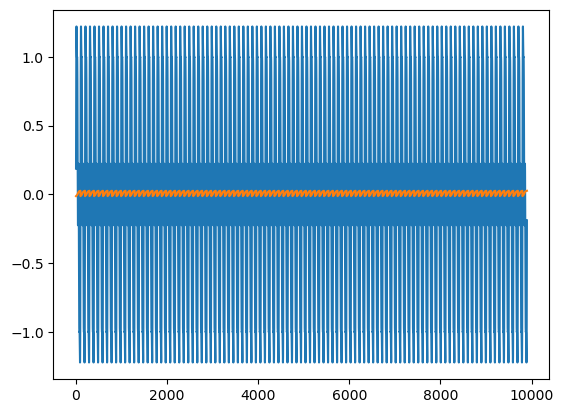

In [46]:
plt.plot(rnn.yR)
plt.plot(rnn.yP)

In [253]:
def theta(x):
    return 0.5*(1 + sign(x))


def f(x):
    return np.tanh(x)


def df(x):
    return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow


class RNN:


    def __init__(self, n_in, n_rec, n_out, tau=10):
        np.random.seed(42)
        self.n_s = 1
        self.n_in = n_in
        self.n_rec = n_rec
        self.n_out = n_out
        self.tau = tau

        self.w_in = 0.1*(np.random.rand(n_rec, n_in) - 1)
        self.w_rec = 1.5*np.random.randn(n_rec, n_rec)/n_rec**0.5
        self.w_out = 0.1*(2*np.random.rand(n_out, n_rec) - 1)/n_rec**0.5

        self.yP = []
        self.yR = []

        self.u = None
        self.hi = np.zeros(n_rec)  # time-dependent RNN activity vector
        self.hf = np.zeros(n_rec)  # time-dependent RNN activity vector

        self.h = np.zeros((self.n_s+1, self.n_rec))
        self.z = np.zeros((self.n_s+1, self.n_rec))
        self.u = np.zeros((self.n_s+1, self.n_rec))
        self.e = np.zeros((self.n_s+1, self.n_out))

    def fit(self, x, yR, eta=[0.1, 0.1, 0.1]):
  
        [eta3, eta2, eta1] = eta 



        for i in range(self.n_s):
            print(i)
            print(self.h[i])
            print(self.w_rec)
            self.u[i+1] = self.h[i] @ self.w_rec + np.dot(self.w_in, x)
            self.h[i+1] = self.h[i] + (-self.h[i] + f(self.u[i+1]))/self.tau
            yP = np.dot(self.w_out,self.h[i+1])
            self.e[i+1] = yP - yR

            #print(dw_out)
            self.yR.append(yR)
            self.yP.append(yP)
        
            self.z[i] = self.z[i+1]*(1-1/self.tau)
            self.z[i] += np.dot((self.w_out).T, self.e[i+1])
            self.z[i] += np.dot(self.z[i+1]*df(self.u[i+1]), self.w_rec)/self.tau

            # Updates for the weights:
            dw_out = eta1*np.outer(self.e[i+1], self.h[i+1])/self.n_s
            dw_rec = eta2/(self.n_s*self.tau)*np.outer(self.z[i+1]*df(self.u[i+1]),
                                                        self.h[i])
            dw_in = eta3/(self.n_s*self.tau)*np.outer(self.z[i+1]*df(self.u[i+1]),
                                                    x[i])
            
            self.w_out = self.w_out + dw_out
            self.w_rec = self.w_rec + dw_rec
            self.w_in = self.w_in + dw_in



In [254]:
n_in, n_rec, n_out = 1, 5, 1  # number of inputs, recurrent units, and outputs
duration = 100  # number of timesteps in one period

sig = np.sin(np.linspace(0, 50, 100))
X,Y = prepare_data(sig,n_in,n_out)

h_init = 0.1*np.ones(n_rec)  # initial state of the RNN
    
rnn = RNN(n_in, n_rec, n_out, h_init)
for x,y in zip(X,Y):
    rnn.fit(x=x,yR=y)

0
[0. 0. 0. 0. 0.]
[[ 0.18718659  0.67787426 -0.3896649  -0.35229462 -0.38329347]
 [-0.61989361 -1.75255116  0.63752736  0.54768801 -1.0222471 ]
 [-0.28714203 -0.49802165 -0.47181737 -1.43530117 -0.42226464]
 [ 0.40096308  1.71695677  0.26445955  0.08198711 -0.34576475]
 [-0.40266252  0.63556195  0.19523154 -0.42634643 -0.68527804]]


ValueError: could not broadcast input array from shape (5,5) into shape (5,)

In [203]:
for t in range(5-1):
    print(t)

for t in range(5-1, 0, -1):
    print(t)

0
1
2
3
4
3
2
1
